# Bimetallic distributions: PDDF, RDF

In this notebook, we demonstrate how to import and analyze both **single-frame** and **multi-frame XYZ files**. For each case, we compute the pair distance 
distribution function (PDDF) in both lattice units and Ångström (Å), and the radial distribution function (RDF).

All analyses in this notebook focus on **bimetallic nanoalloyes**.
With respect to the "monometallic distribution Jupyter notebook," fewer examples will be displayed here. Users can easily add more by using the print() function.

### Notebook Structure

1. Setup
- Import the required libraries  
- Define the absolute working path  
- Adjust Jupyter display settings for improved output readability  


2. Single-Frame Analysis
- 2.1 Define input parameters and file paths  
- 2.2 Read the XYZ file  
- 2.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 2.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 2.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  


3. Multi-Frame Analysis
- 3.1 Define input parameters and file paths  
- 3.2 Read the XYZ file  
- 3.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 3.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 3.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  

## Set the stage

In [1]:
# import snow libraries
from snow.io.xyz import *
from snow.descriptors.distributions import *

In [2]:
# import other required-useful libraries

import numpy as np
# set a continuous printoption for the print in a jupyter-notebook
np.set_printoptions(threshold=np.inf)

import matplotlib.pyplot as plt #to plot
xfig=4
yfig=3

In [3]:
# check your absolute path and save in a variable
absolute_path = ! pwd
absolute_path = absolute_path[0]
absolute_path

'/Users/szinzani/Documents/Codici/pySNOW/tutorial'

# Let's begin - Single frame xyz file

In [4]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="Au52Rh19.xyz"


element_A='Au'
element_B='Rh'

my_lattice_A=4.079
my_lattice_B=3.084
my_lattice_mean=(my_lattice_A+my_lattice_B)/2


**!** take care about what lattice you would like to use in the following functions: the choice of the lattice is fundamental and will change a lot your results

In [5]:
# Here the code read the xyz file
el, coords= read_xyz(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=len(coords)
print(nframe)

71


## PDDF in \AA

### Global PDDF in \AA

In [6]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_mean

pddf = pddf_calculator(coords, bin_width = my_bin_size_aa, use_lattice_units=False)

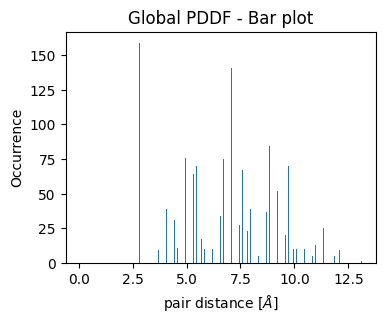

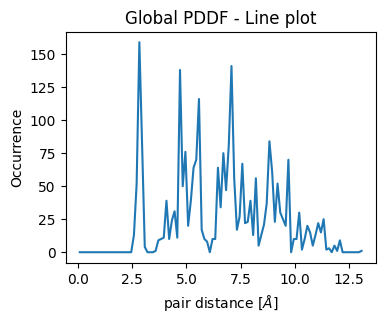

In [7]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("Global PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("Global PDDF - Line plot")
plt.show()

### Chemical PDDF in \AA

In [8]:
# For A–A pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_A = my_bin_size_lattice*my_lattice_A

pddf = pddf_calculator_by_elements(coords, el, [element_A, element_A], bin_width = my_bin_size_aa_A, use_lattice_units=False)

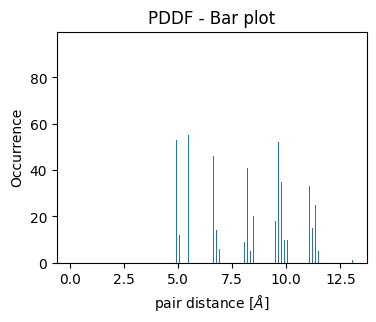

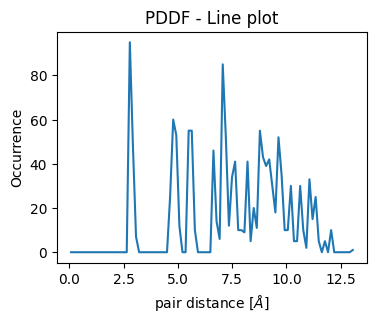

In [9]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

In [10]:
# For B–B pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_B = my_bin_size_lattice*my_lattice_B

pddf = pddf_calculator_by_elements(coords, el, [element_B, element_B], bin_width = my_bin_size_aa_B, use_lattice_units=False)


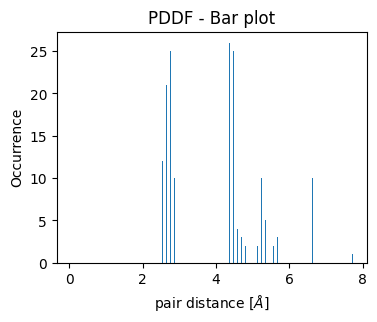

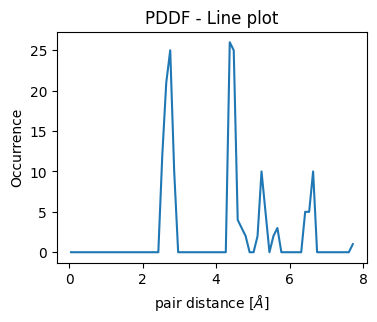

In [11]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

In [12]:
#For A–B pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_AB = my_bin_size_lattice*my_lattice_mean

pddf = pddf_calculator_by_elements(coords, el, [element_A, element_B], bin_width = my_bin_size_aa_AB, use_lattice_units=False)

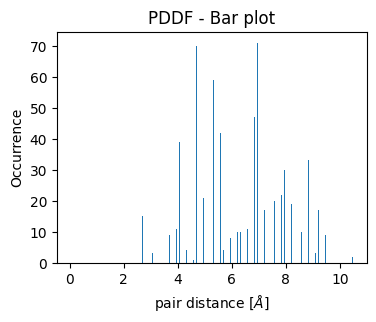

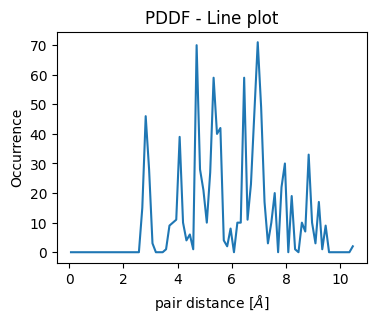

In [13]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

## RDF

In [14]:
# split coords and el depending on the chemical species
coords_A = []
el_A = []
coords_B = []
el_B = []

for i in range(len(el)):
    if el[i] == element_A:
        coords_A.append(coords[i])
        el_A.append(el[i])

    elif el[i] == element_B:
        coords_B.append(coords[i])
        el_B.append(el[i])

    else:
        print("error: the elements provided does not match with your file")

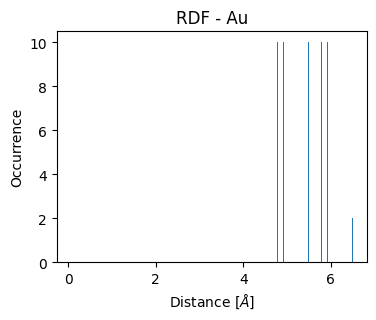

In [15]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_A

#com_rdf = com_rdf_calculator(coords, elements=el, bin_width = my_bin_size_aa)
com_rdf_A = com_rdf_calculator(coords_A, bin_width = my_bin_size_aa, elements=el_A)

plt.figure(figsize=(xfig, yfig))
plt.bar(com_rdf_A[0], com_rdf_A[1], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - "+element_A)
plt.show()

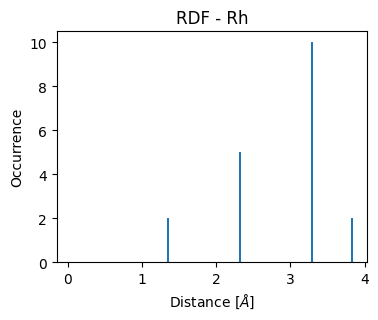

In [16]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_B

#com_rdf = com_rdf_calculator(coords, elements=el, bin_width = my_bin_size_aa)
com_rdf_B = com_rdf_calculator(coords_B, bin_width = my_bin_size_aa, elements=el_B)

plt.figure(figsize=(xfig, yfig))
plt.bar(com_rdf_B[0], com_rdf_B[1], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - "+element_B)
plt.show()

# Let's begin - Multiple frame xyz file

In [17]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="movie-separated.xyz"

element_A='Au'
element_B='Pt'

my_lattice_A=4.079
my_lattice_B=3.92
my_lattice_mean=(my_lattice_A+my_lattice_B)/2

In [18]:
# Here the code read the xyz file
el, coords= read_xyz_movie(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=len(coords)
print(nframe)

2309


## PDDF in \AA

### Global PDDF in \AA

In [19]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator(coords[t], bin_width = my_bin_size_aa, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

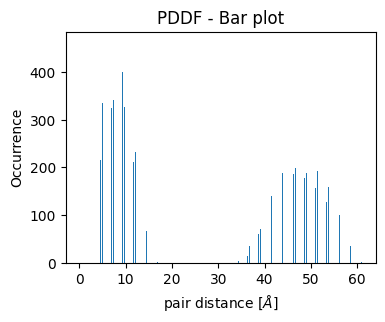

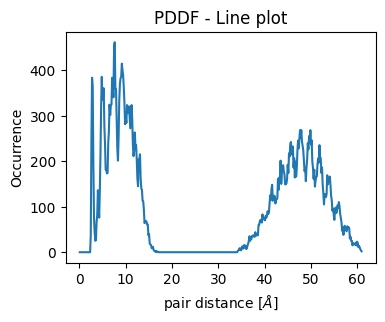

In [20]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

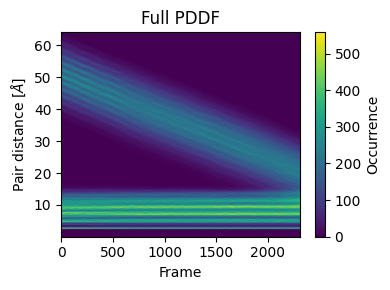

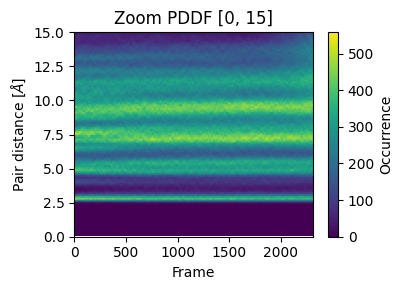

In [21]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("Full PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For A-A pairs

In [22]:
my_bin_size_lattice = 0.035
my_bin_size_aa_A = my_bin_size_lattice*my_lattice_A

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(coords[t], el[t], [element_A, element_A], bin_width = my_bin_size_aa_A, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

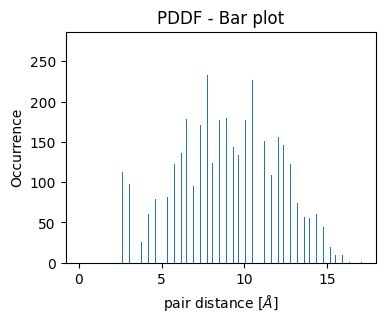

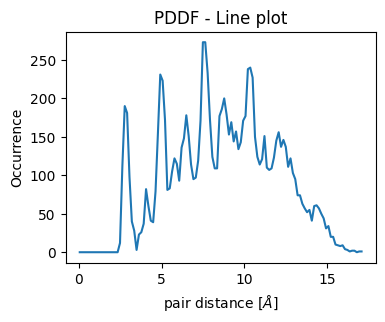

In [23]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

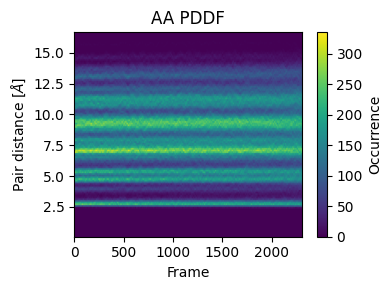

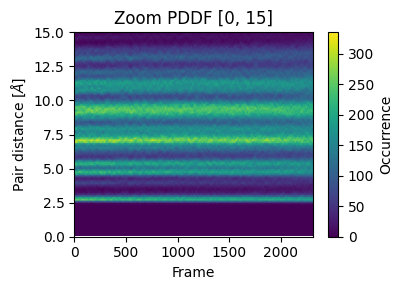

In [37]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("AA PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For B-B pairs

In [33]:
my_bin_size_lattice = 0.035
my_bin_size_aa_B = my_bin_size_lattice*my_lattice_B

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(coords[t], el[t], [element_B, element_B], bin_width = my_bin_size_aa_B, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

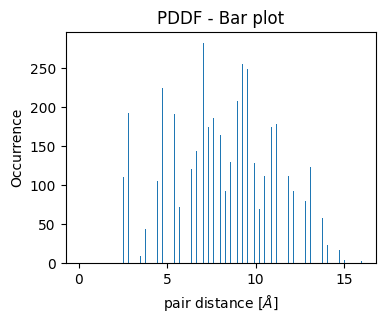

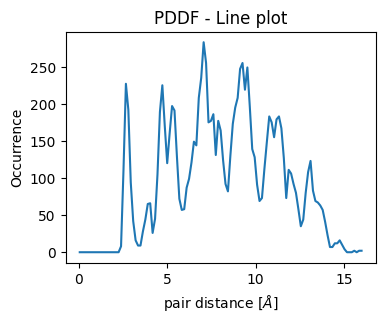

In [34]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

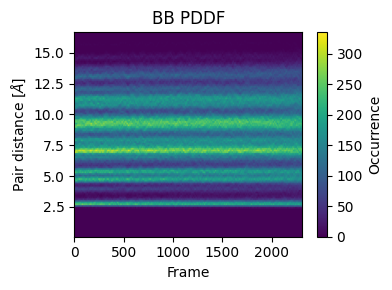

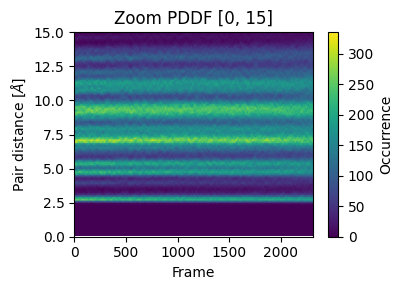

In [36]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("BB PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For A-B pairs

In [39]:
my_bin_size_lattice = 0.035
my_bin_size_aa_AB = my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(coords[t], el[t], [element_A, element_B], bin_width = my_bin_size_aa_AB, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

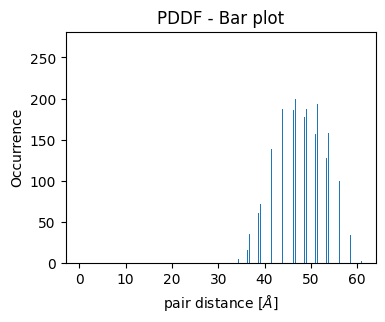

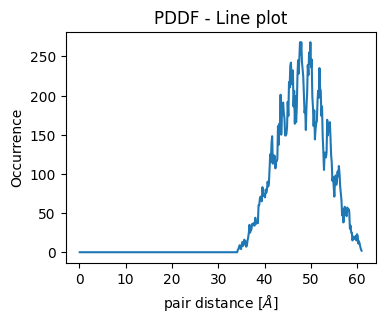

In [40]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

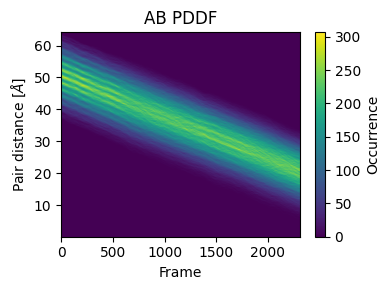

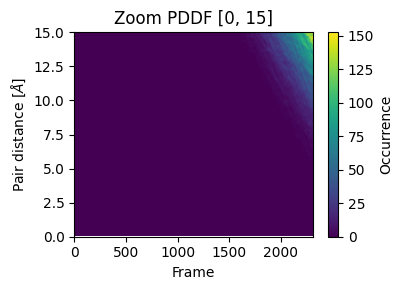

In [41]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("AB PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

## RDF

[7.61900025e-04 7.61969036e-04 2.48736994e+01]


### Global RDF

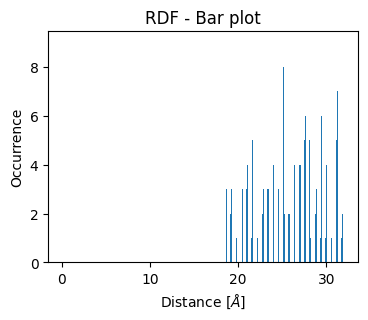

In [63]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf = com_rdf_calculator(coords[t], bin_width = my_bin_size_aa, elements= el[t])

    bins_list.append(com_rdf[0])
    occ_list.append(com_rdf[1])

t=20
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

### Chemical RDF 

In [52]:
### ARRIVATA QUI


# split coords and el depending on the chemical species

coords_A_list = []
el_A_list = []
coords_B_list = []
el_B_list = []

#for t in range(nframe):
for el_t, coords_t in zip(el, coords):

    coords_A = []
    el_A = []
    coords_B = []
    el_B = []


    #coords_t = coords[t]
    #el_t = el[t]

    for e, coord in zip(el_t, coords_t):
        if e == element_A:
            coords_A.append(coord)
            el_A.append(e)
        elif e == element_B:
            coords_B.append(coord)
            el_B.append(e)
        else:
            print(f"Error: element {e} does not match {element_A} or {element_B}")

    coords_A_list.append(coords_A)
    coords_B_list.append(coords_B)
    el_A_list.append(el_A)
    el_B_list.append(el_B)



In [53]:
from snow.descriptors.shape_descriptors import *
print(center_of_mass(coords[0], el[0]))
print(center_of_mass(coords_A_list[0], el_A_list[0]))
print(center_of_mass(coords_B_list[0], el_B_list[0]))

[7.61900025e-04 7.61969036e-04 2.48736994e+01]
[-0.03123633 -0.03123605 -0.0312366 ]
[3.30701361e-02 3.30700000e-02 5.00199227e+01]


#### Chemical RDF - Element A

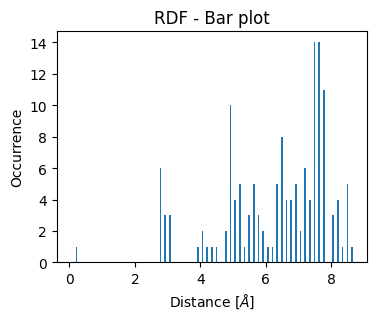

147


In [61]:


my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_A


bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf_A = com_rdf_calculator(coords_A_list[t], elements=el_A_list[t], bin_width = my_bin_size_aa)
    bins_list.append(com_rdf_A[0])
    occ_list.append(com_rdf_A[1])


t=200
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()


print(np.sum(occ_list[0]))

#### Chemical RDF - Element B

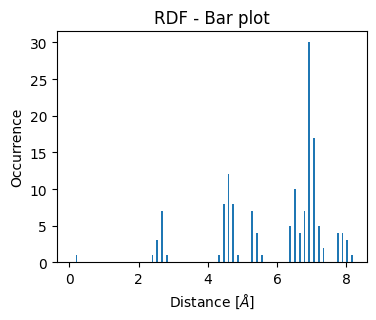

147


In [65]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_B


bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf_B = com_rdf_calculator(coords_B_list[t], elements=el_B_list[t], bin_width = my_bin_size_aa)
    bins_list.append(com_rdf_B[0])
    occ_list.append(com_rdf_B[1])

t=200
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

print(np.sum(occ_list[0]))

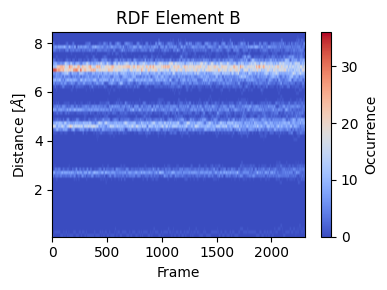

In [66]:
# Create a common grid for different possible lenght of RDF at different frames
nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)


plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='coolwarm'
)
plt.xlabel("Frame")
plt.ylabel("Distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("RDF Element B")
plt.tight_layout()
plt.show()
